# Prédiction du risque de burnout à partir de données comportementales

> ⚠️ **Cadre éthique** — outil d'**alerte précoce** (RH / bien-être personnel),
> pas de diagnostic médical. Données **entièrement synthétiques**. Un tel
> système soulève des enjeux forts de **vie privée** et de **biais** discutés en
> fin de notebook — ils font partie du livrable.

**Angle décisionnel** — repérer, à partir de signaux comportementaux (temps
d'écran, travail, sommeil, mobilité, sociabilité), des profils à risque de
surcharge **avant** qu'ils ne deviennent critiques.

**Données** — aucun jeu réel de traces comportementales brutes labellisées
n'est éthiquement exploitable publiquement. On **simule** 1 200 personnes ×
56 jours avec une structure causale explicite : un stress latent caché génère
les comportements, et le **label de burnout est tiré des comportements
réellement observés** (pas du latent) — le modèle doit donc apprendre un signal
*récupérable*, comme un vrai système d'alerte.

**Plan** : données → features → profils (non supervisé) → score de risque
(supervisé) → SHAP → limites & éthique.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from features import load_features, FEATURE_COLS

feats = load_features()
print(f"{len(feats)} personnes | {len(FEATURE_COLS)} features")
print(f"prévalence burnout : {feats.burnout.mean()*100:.1f}%")
feats[["person_id"] + FEATURE_COLS + ["burnout"]].head()

1200 personnes | 9 features
prévalence burnout : 29.2%


,person_id,work_hours_mean,screen_evening_mean,weekend_work_ratio,sleep_mean,steps_mean,social_mean,sleep_var,onset_var,routine_break,burnout
0,0,7.510357,2.583036,0.372186,6.317321,6022.089286,30.267857,1.038055,0.756147,1.614286,0
1,1,7.507321,2.899107,0.421462,6.550893,6013.892857,30.982143,0.834600,0.857871,1.494214,0
2,2,8.066250,3.201250,0.399071,6.189643,7540.678571,27.625000,0.954880,0.934168,1.805143,0
3,3,7.412500,2.943393,0.435644,6.120893,7186.821429,26.339286,1.049605,0.885764,0.356714,0
4,4,7.807857,3.379821,0.495944,6.044107,6075.071429,26.089286,1.149268,0.932382,0.894571,0


## 1. Des features interprétables, en trois familles

**Surcharge** (travail, écran du soir, travail le week-end), **récupération**
(sommeil, pas, messages sociaux), **régularité** (variabilité du sommeil et de
l'heure de coucher, rupture de routine). On regarde leur corrélation brute avec
l'issue — diagnostic, pas modèle.

In [2]:
corr = feats[FEATURE_COLS + ["burnout"]].corr()["burnout"].drop("burnout")
display(corr.sort_values(key=abs, ascending=False).round(3).to_frame(
    "corrélation avec burnout"))

,corrélation avec burnout
screen_evening_mean,0.708
social_mean,-0.695
onset_var,0.669
work_hours_mean,0.653
sleep_var,0.629
sleep_mean,-0.589
weekend_work_ratio,0.576
steps_mean,-0.480
routine_break,0.048


**Lecture** — l'écran du soir (+0,71), le retrait social (−0,70), l'irrégularité
du coucher (+0,67) et les heures de travail (+0,65) sont les plus liés. La
*rupture de routine* est faible ici (fenêtre courte, sans tendance forte) — une
feature honnêtement peu informative, conservée pour transparence.

## 2. Profils comportementaux (non supervisé)

K-Means (K par silhouette) sur les features standardisées, **sans utiliser le
label**. On regarde ensuite le taux de burnout par profil : une segmentation
purement comportementale porte-t-elle déjà le risque ?

,cluster,n,burnout_rate,work,screen,sleep,sleep_var,steps,social
0,0,574,0.59,7.86,3.26,6.02,1.10,6601.35,24.78
1,1,626,0.02,6.82,2.31,6.59,0.85,7808.17,32.81


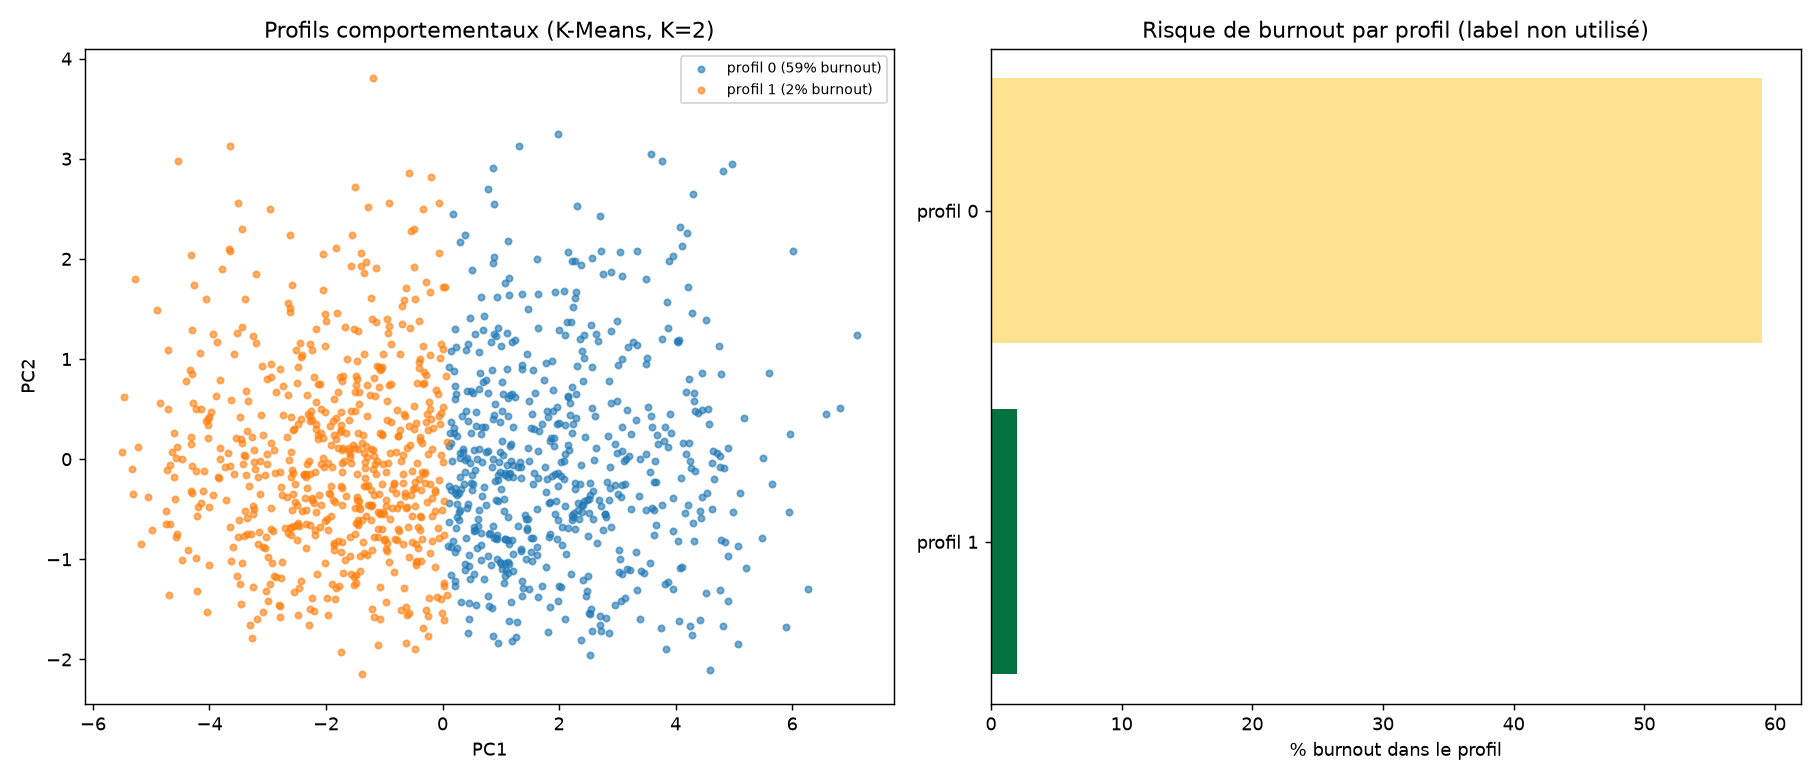

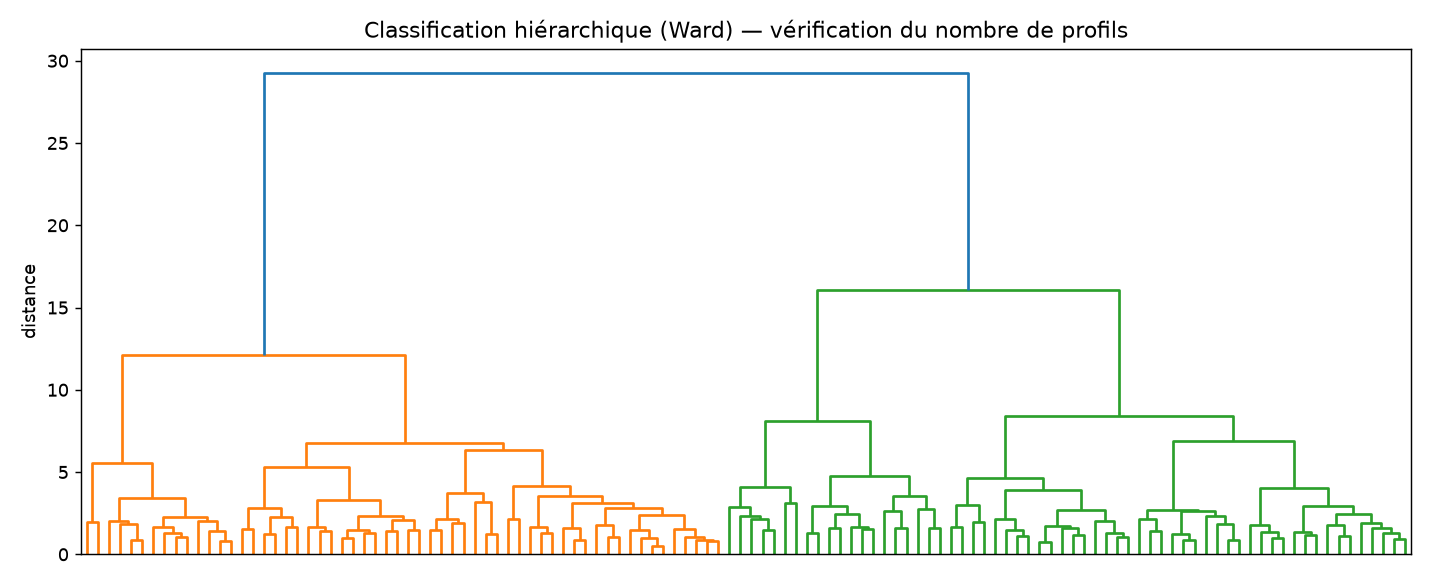

In [3]:
prof = pd.read_csv(ROOT / "reports" / "cluster_profiles.csv")
display(prof.round(2))
display(Image(ROOT / "reports" / "figures" / "behavioral_clusters.png", width=880))
display(Image(ROOT / "reports" / "figures" / "dendrogram.png", width=720))

**Lecture** — deux archétypes émergent : un profil **« surchargé »** (travail et
écran élevés, sommeil bas, peu de pas/social) avec **~59 % de burnout**, et un
profil **« équilibré »** à **~2 %**. La segmentation comportementale seule
sépare donc déjà fortement le risque — et le dendrogramme Ward confirme la
stabilité du nombre de profils.

## 3. Score de risque supervisé

Classifieur (Gradient Boosting vs régression logistique) sur les 9 features
(le stress latent et la probabilité vraie sont **retirés** — pas de fuite).
Métriques adaptées : ROC-AUC et PR-AUC sur un test tenu à l'écart.

In [4]:
metrics = pd.read_csv(ROOT / "reports" / "model_metrics.csv")
display(metrics.round(3))

,model,roc_auc,pr_auc,brier
0,LogReg (balanced),0.962,0.909,NaN
1,GradientBoosting,0.951,0.885,0.084


**Lecture** — le risque est bien prédictible (ROC-AUC ≈ 0,95-0,96 ; PR-AUC
≈ 0,89-0,91). La régression logistique fait jeu égal, ce qui est rassurant : le
signal est largement **linéaire et interprétable**, pas un artefact d'un modèle
complexe.

## 4. Explicabilité (SHAP) — pourquoi ce score ?

Un outil RH/bien-être doit être **transparent et actionnable**. SHAP explique le
modèle globalement (quels comportements pèsent) et individuellement (le
décompte de risque d'une personne).

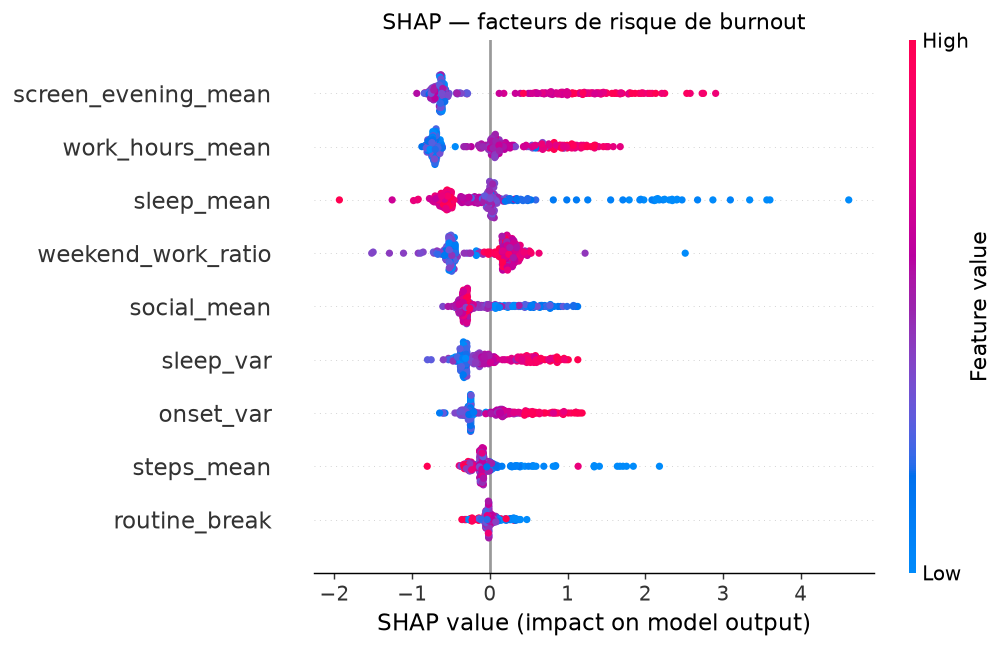

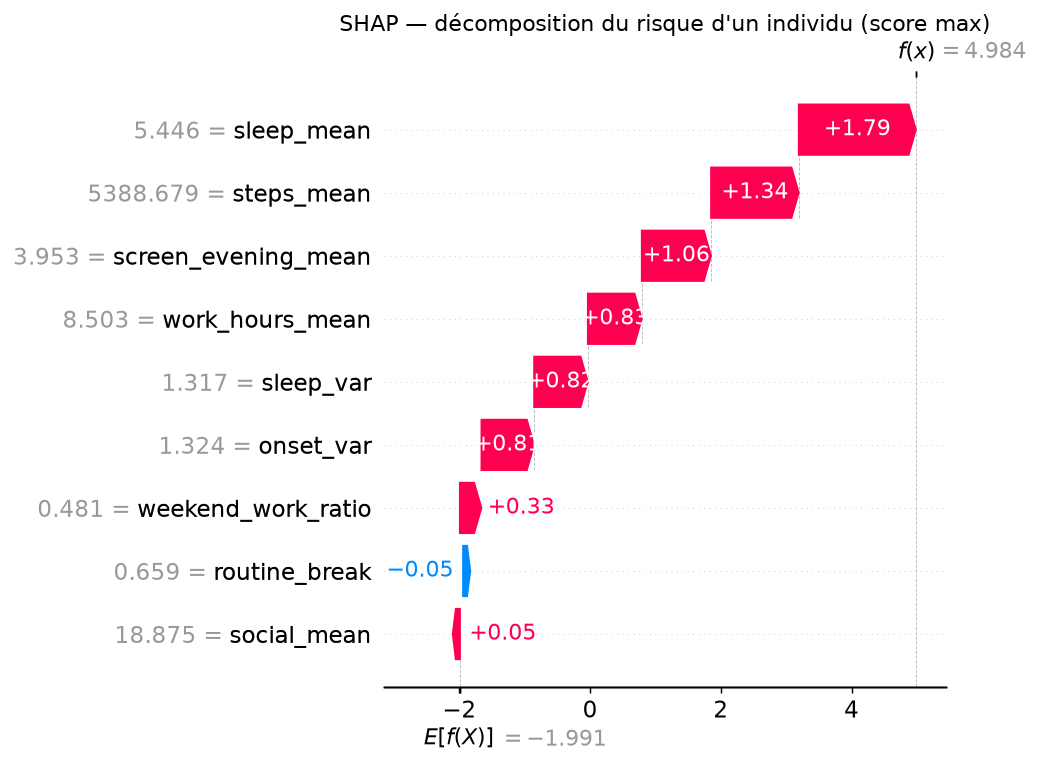

,feature,mean_abs_shap
0,screen_evening_mean,0.852
1,work_hours_mean,0.563
2,sleep_mean,0.516
3,weekend_work_ratio,0.378
4,social_mean,0.348
5,sleep_var,0.343
6,onset_var,0.329
7,steps_mean,0.209
8,routine_break,0.083


In [5]:
for fig in ["shap_beeswarm.png", "shap_waterfall.png"]:
    display(Image(ROOT / "reports" / "figures" / fig, width=640))
imp = pd.read_csv(ROOT / "reports" / "shap_importance.csv")
display(imp.round(3))

**Lecture** — les facteurs dominants (écran du soir, heures de travail, manque
de sommeil, travail le week-end, retrait social) sont **cohérents et
actionnables** : ils suggèrent des leviers concrets (hygiène numérique du soir,
charge de travail, récupération le week-end). Le *waterfall* fournit la vue
individuelle indispensable à un accompagnement personnalisé.

## 5. Limites & éthique *(centrales pour ce projet)*

**Données**
- **Entièrement synthétiques** : les performances élevées reflètent en partie la
  structure causale que nous avons encodée. Sur données réelles, bruitées et
  confondues, les scores seraient plus bas et les biais bien réels.
- Un vrai déploiement devrait combiner un jeu proche (ex. *Mental Health in Tech
  Survey*) et une collecte consentie, jamais des traces à l'insu des personnes.

**Éthique & vie privée (non négociable)**
- **Surveillance** : suivre écran/mobilité/sommeil est hautement intrusif. Un
  tel outil n'est acceptable qu'avec **consentement explicite**, **contrôle par
  la personne**, minimisation et traitement local/chiffré.
- **Finalité** : à visée de **prévention et de soutien**, jamais de sanction, de
  tri RH ou de décision d'emploi. Un score de risque ne doit pas devenir un
  outil de contrôle.
- **Biais & faux positifs** : un modèle appris sur une population peut mal
  généraliser (âge, culture, neurodiversité) ; un faux positif peut stigmatiser.
  Score explicable, seuil transparent, et **humain dans la boucle** obligatoires.
- **Pas un diagnostic** : le burnout est clinique ; cet outil signale un
  *risque comportemental*, à confronter à un accompagnement humain qualifié.